In [2]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd
#from scipy.io import savemat
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import cm

In [3]:
#load file for all dates
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

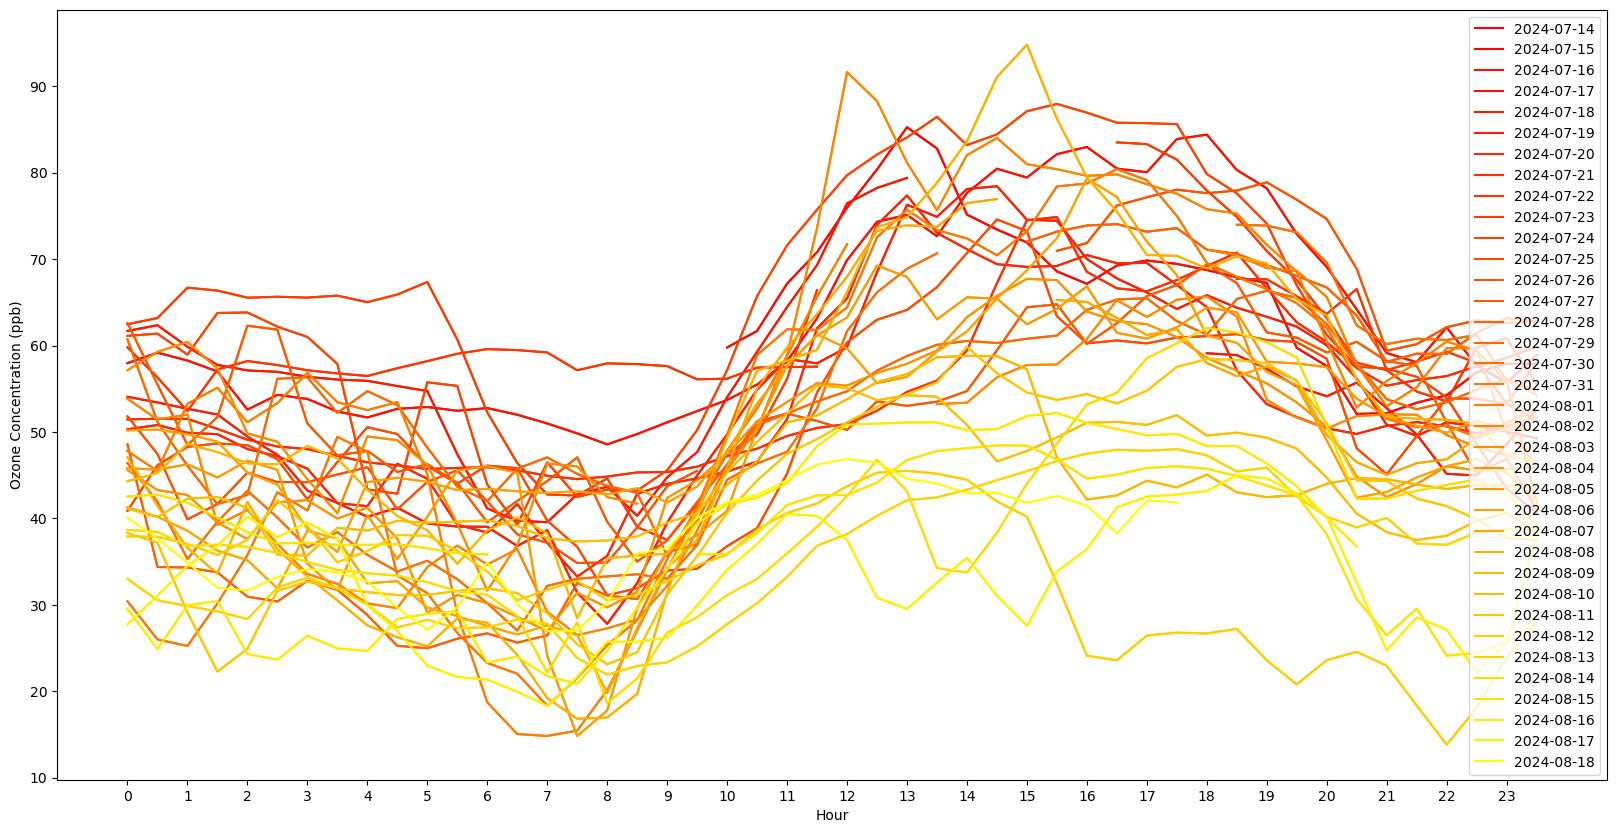

In [18]:
fig, ax = plt.subplots(figsize = (20,10))
hour_range = np.arange(0,24,0.5)

# color = cm.rainbow(np.linspace(0,1,15))
cmap = plt.get_cmap('autumn',1680)

for day_val in range(12,len(df_alldays.index)-36,48):
    days_indexing = df_alldays.index.date[day_val]
    one_day_df = df_alldays.sort_index().loc[str(days_indexing)]
    ozone_vals = one_day_df['O3_ppbv'].values
    plt.plot(hour_range, ozone_vals, color=cmap(day_val))

    plt.xlabel('Hour')
    plt.ylabel('Ozone Concentration (ppb)')
    plt.xticks(np.arange(0,24))

first_day_indexing = df_alldays.index.date[0]
first_day_locating = df_alldays.sort_index().loc[str(first_day_indexing)]
first_day_ozone_vals = first_day_locating['O3_ppbv'].values
first_day_ozone_pad = np.pad(first_day_ozone_vals, pad_width = (36,0),mode='constant',constant_values = np.nan)
plt.plot(hour_range,first_day_ozone_pad, color=cmap(0), label=str(first_day_indexing))

for day_val in range(12,len(df_alldays.index)-36,48):
    days_indexing = df_alldays.index.date[day_val]
    one_day_df = df_alldays.sort_index().loc[str(days_indexing)]
    ozone_vals = one_day_df['O3_ppbv'].values
    plt.plot(hour_range, ozone_vals, label = days_indexing, color=cmap(day_val))

last_day_indexing = df_alldays.index.date[1679]
last_day_locating = df_alldays.sort_index().loc[str(last_day_indexing)]
last_day_ozone_vals = last_day_locating['O3_ppbv'].values
last_day_ozone_pad = np.pad(last_day_ozone_vals, pad_width = (0,12),mode='constant',constant_values = np.nan)
plt.plot(hour_range,last_day_ozone_pad, color=cmap(1679), label=str(last_day_indexing))

plt.legend()

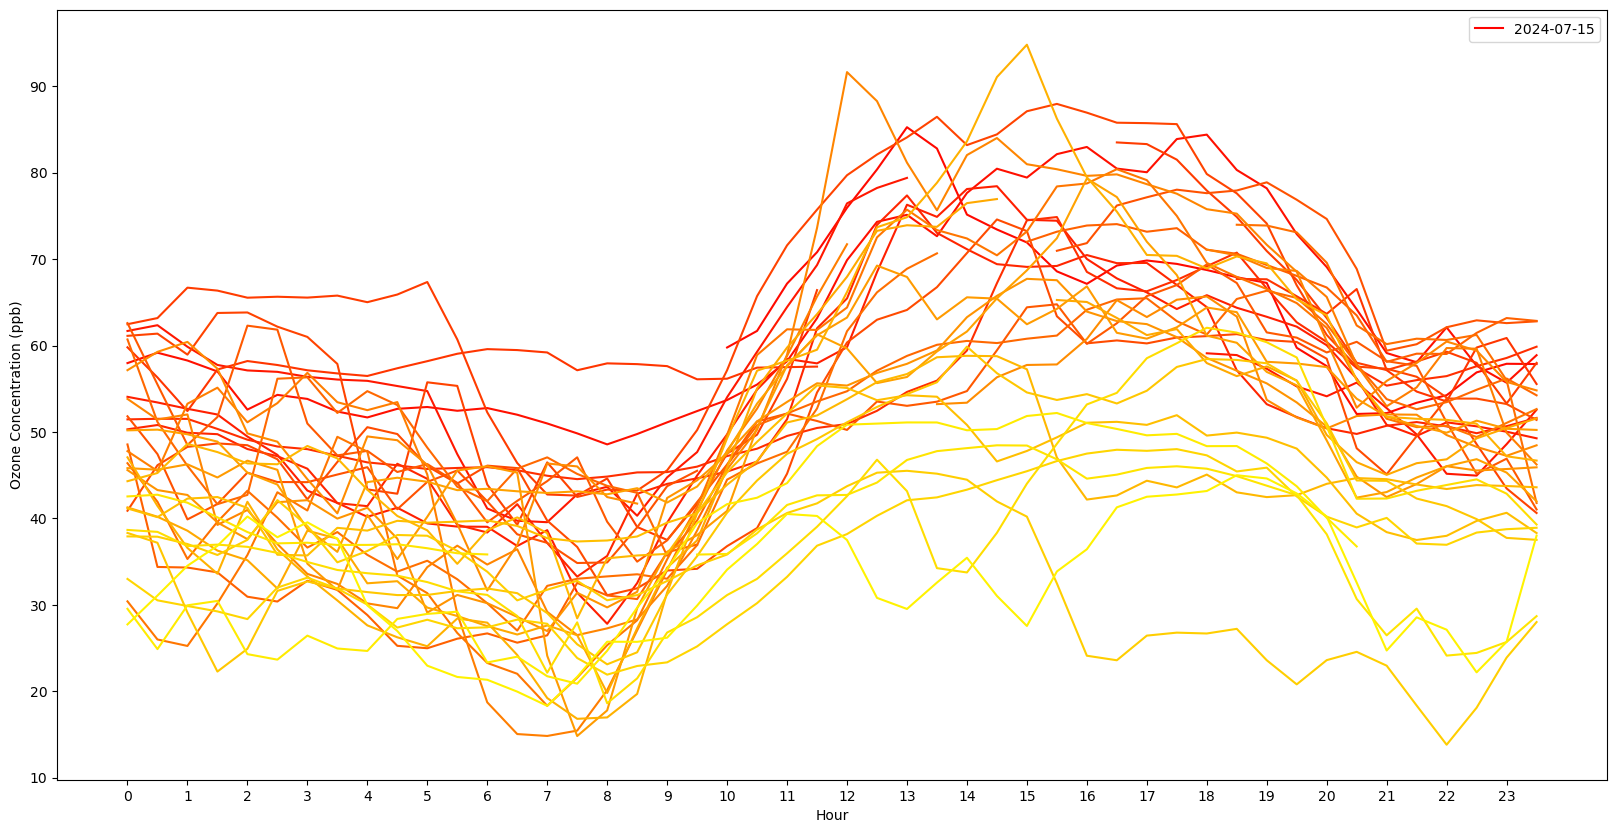

In [23]:
#Trying to figure out how to work in the first and last value into the loop to be included in the plot

fig, ax = plt.subplots(figsize = (20,10))
hour_range = np.arange(0,24,0.5)
lines = []

cmap = plt.get_cmap('autumn',1680)

for day_val in range(0,len(df_alldays.index)-36,48):
    if day_val == 0:
        first_day_indexing = df_alldays.index.date[0]
        first_day_locating = df_alldays.sort_index().loc[str(first_day_indexing)]
        first_day_ozone_vals = first_day_locating['O3_ppbv'].values
        first_day_ozone_pad = np.pad(first_day_ozone_vals, pad_width = (36,0),mode='constant',constant_values = np.nan)
        continue
    if day_val == 
    days_indexing = df_alldays.index.date[day_val]
    one_day_df = df_alldays.sort_index().loc[str(days_indexing)]
    ozone_vals = one_day_df['O3_ppbv'].values
    to_plot, = ax.plot(hour_range,ozone_vals, color=cmap(day_val))
    lines.append(to_plot)

selected_handles = [lines[0]]
selected_labels = [str(df_alldays.index.date[13])]
ax.legend(selected_handles, selected_labels)

plt.xlabel('Hour')
plt.ylabel('Ozone Concentration (ppb)')
plt.xticks(np.arange(0,24))
plt.show()